# Test PIT

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
import numpy as np
from scipy.interpolate import interp1d

In [2]:
sys.path.append('X:/Software/python_verification/')
import vrf_scores

In [3]:
def empirical_cdf_bounds(ensemble, x):
    ensemble = np.asarray(ensemble)
    n = len(ensemble)
    Fx_minus = np.sum(ensemble < x) / n
    Fx = np.sum(ensemble <= x) / n
    return Fx_minus, Fx

In [4]:
def empirical_cdf_bounds_plotpos(ensemble, x, plot_pos='hazen'):
    ensemble = np.asarray(ensemble)
    x_sorted = np.sort(ensemble)
    n = len(x_sorted)

    # Plotting position parameters
    def get_plotting_position_params(pos):
        pos = pos.lower()
        if pos == 'weibull': return 0.0, 1.0
        elif pos == 'median': return 0.3175, 0.365
        elif pos == 'apl': return 0.35, 0.0
        elif pos == 'blom': return 0.375, 0.25
        elif pos == 'cunnane': return 0.4, 0.2
        elif pos == 'gringorten': return 0.44, 0.12
        elif pos == 'hazen': return 0.5, 0.0
        else: raise ValueError("Unknown plotting position")

    p1, p2 = get_plotting_position_params(plot_pos)
    # Compute plotting positions
    pp = ((np.arange(1, n + 1) - p1) / (n + p2))

    # Remove duplicates using last occurrence (like MATLAB)
    _, ind = np.unique(x_sorted[::-1], return_index=True)
    ind = np.sort(n - 1 - ind)
    x_unique = x_sorted[ind]
    pp_unique = pp[ind]

    # Compute F(x⁻) and F(x)
    mask_lt = x_unique < x
    mask_le = x_unique <= x

    if not np.any(mask_lt):
        Fx_minus = 0.0
    else:
        Fx_minus = pp_unique[mask_lt][-1]

    if not np.any(mask_le):
        Fx = 0.0
    else:
        Fx = pp_unique[mask_le][-1]

    return Fx_minus, Fx


In [6]:
def pit_sample_empirical(ensemble, x, plot_pos=None):
    if plot_pos is not None:
        Fx_minus, Fx = empirical_cdf_bounds_plotpos(ensemble, x, plot_pos)
    else:
        Fx_minus, Fx = empirical_cdf_bounds(ensemble, x)
    return uniform.rvs(loc=Fx_minus, scale=Fx - Fx_minus)

In [8]:
def compute_pit_values(ensembles, observations):
    """
    Compute PIT values for a list of forecast ensembles and observations.

    Parameters:
        ensembles (list of arrays): Forecast ensemble for each observation.
        observations (array-like): Observed values.

    Returns:
        list: PIT values.
    """
    pit_values = []
    for ens, obs in zip(ensembles, observations):
        pit = pit_sample_empirical(ens, obs)
        pit_values.append(pit)
    return np.array(pit_values)


In [12]:
def compute_pit_custom_plotpos(forecasts,obs,plot_pos='weibull',
                               extrapval_min=0.0, extrapval_max=1.0):
    """
    Compute PIT values using custom plotting positions and linear interpolation.

    Parameters:
        obs (array): Observations (length N)
        forecasts (2D array): Forecast ensembles (shape N x M)
        plot_pos (str or [p1, p2]): Plotting position method or custom tuple
        extrapval_min (float): CDF value to assign when obs < min(ensemble)
        extrapval_max (float): CDF value to assign when obs > max(ensemble)

    Returns:
        pit_values (array): PIT values (between 0 and 1)
    """
    obs = np.asarray(obs)
    forecasts = np.asarray(forecasts)
    N, M = forecasts.shape
    pit_values = np.zeros(N)

    p1, p2 = get_plotting_position_params(plot_pos)

    for i in range(N):
        ens = forecasts[i]
        x = np.sort(ens)
        
        # Ensure uniqueness
        xx, ind = np.unique(x, return_index=True)
        nj = len(xx)

        if nj == 1:
            # Only one unique value
            pit_values[i] = 0.0 if obs[i] < xx[0] else 1.0
            continue

        # Plotting positions
        pp = ((np.arange(1, nj + 1) - p1) / (nj + p2))

        # Interpolate
        f_interp = interp1d(xx, pp, bounds_error=False,
                            fill_value=(extrapval_min, extrapval_max))

        pit_values[i] = f_interp(obs[i])

    return pit_values

In [13]:
def unique_last(x):
    x = np.asarray(x)
    reversed_idx = np.arange(len(x))[::-1]
    _, reverse_ind = np.unique(x[::-1], return_index=True)
    ind = reversed_idx[reverse_ind]
    return x[ind], np.sort(ind)


In [ ]:
# Plotting position parameters
def get_plotting_position(n, plot_pos):
    plot_pos = plot_pos.lower()
    if plot_pos == 'weibull':
        p1, p2 = 0.0, 1.0
    elif plot_pos == 'median':
        p1, p2 = 0.3175, 0.365
    elif plot_pos == 'apl':
        p1, p2 = 0.35, 0.0
    elif plot_pos == 'blom':
        p1, p2 = 0.375, 0.25
    elif plot_pos == 'cunnane':
        p1, p2 = 0.4, 0.2
    elif plot_pos == 'gringorten':
        p1, p2 = 0.44, 0.12
    elif plot_pos == 'hazen':
        p1, p2 = 0.5, 0.0
    else:
        raise ValueError("Unknown plotting position name")

    pp = ((np.arange(1, n + 1) - p1) / (n + p2))
    return pp

In [ ]:
def pit_ecdf(forecasts, obs, plot_pos='hazen', extrapval_min=0.0, extrapval_max=1.0):
    '''
    To do: censoring thershold
    '''
    forecasts = np.atleast_2d(forecasts)
    obs = np.atleast_1d(obs)

    if forecasts.shape[0] != len(obs):
        if forecasts.shape[1] == len(obs):  # if user passed (n_members, n_samples) instead of (n_samples, n_members)
            forecasts = forecasts.T
        else:
            raise ValueError("Forecasts and observations must align in the number of samples.")

    N, M = forecasts.shape
    pit_values = np.zeros(N)

    for f in range(N):
        x = np.sort(forecasts[f, :])
        nj = len(x)

        # Get plotting positions
        pp = get_plotting_position(nj, plot_pos)

        # Remove duplicate ensemble values
        xx, ind = unique_last(x)
        pp = pp[ind]
        #print(pp)

        xq = obs[f]
        if len(xx) == 1:
            pit = 1.0 if xq >= xx[0] else 0.0
        else:
            interp_func = interp1d(xx, pp, bounds_error=False,
                                   fill_value=(extrapval_min, extrapval_max))
            pit = interp_func(xq)

        pit_values[f] = pit

    return pit_values


In [15]:

# Compute PIT using 'Blom' plotting position
pit_vals1 = compute_pit_custom_plotpos(forecast_ensembles, observations, plot_pos='hazen')


[0.00125 0.00375 0.00625 0.00875 0.01125 0.01375 0.01625 0.01875 0.02125
 0.02375 0.02625 0.02875 0.03125 0.03375 0.03625 0.03875 0.04125 0.04375
 0.04625 0.04875 0.05125 0.05375 0.05625 0.05875 0.06125 0.06375 0.06625
 0.06875 0.07125 0.07375 0.07625 0.07875 0.08125 0.08375 0.08625 0.08875
 0.09125 0.09375 0.09625 0.09875 0.10125 0.10375 0.10625 0.10875 0.11125
 0.11375 0.11625 0.11875 0.12125 0.12375 0.12625 0.12875 0.13125 0.13375
 0.13625 0.13875 0.14125 0.14375 0.14625 0.14875 0.15125 0.15375 0.15625
 0.15875 0.16125 0.16375 0.16625 0.16875 0.17125 0.17375 0.17625 0.17875
 0.18125 0.18375 0.18625 0.18875 0.19125 0.19375 0.19625 0.19875 0.20125
 0.20375 0.20625 0.20875 0.21125 0.21375 0.21625 0.21875 0.22125 0.22375
 0.22625 0.22875 0.23125 0.23375 0.23625 0.23875 0.24125 0.24375 0.24625
 0.24875 0.25125 0.25375 0.25625 0.25875 0.26125 0.26375 0.26625 0.26875
 0.27125 0.27375 0.27625 0.27875 0.28125 0.28375 0.28625 0.28875 0.29125
 0.29375 0.29625 0.29875 0.30125 0.30375 0.30625 0.

In [16]:
np.mean(pit_vals),np.mean(pit_vals1)

(np.float64(0.5141375), np.float64(0.5141319018227706))

## Python Code to Visualize F(x) and F(x-)

[0.1 0.3 0.5 0.7 0.9]
[0.1 0.3 0.7 0.9]


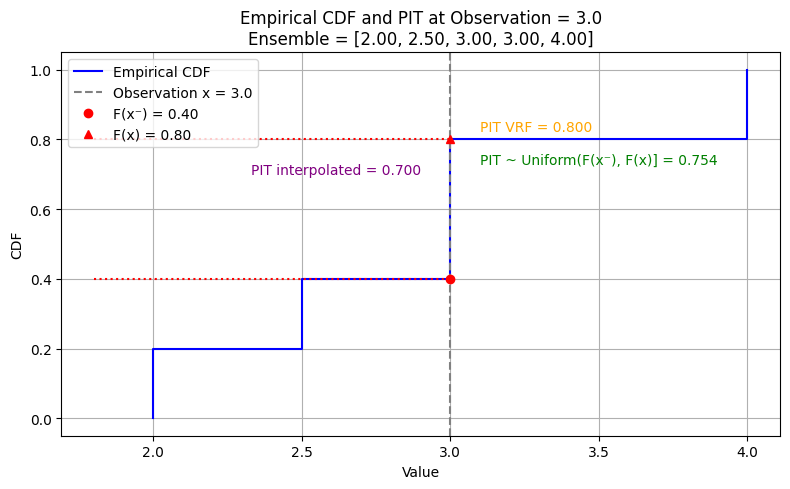

In [ ]:
# Sample ensemble forecast (discrete values)
ensemble = np.array([2.0, 2.5, 3.0, 3.0, 4.0])
observation = 3.0

# Sort ensemble
ensemble_sorted = np.sort(ensemble)
n = len(ensemble)

# Compute step ECDF values
x_vals = ensemble_sorted
y_vals = np.arange(1, n + 1) / n

# Build x/y for step plot
x_plot = np.repeat(x_vals, 2)
y_plot = np.hstack(([0], np.repeat(y_vals[:-1], 2), [y_vals[-1]]))

# F(x-) and F(x)
F_x_minus = np.sum(ensemble < observation) / n
F_x = np.sum(ensemble <= observation) / n

pit_sampled = pit_sample_empirical(ensemble, observation)
pit_interpolated = pit_custom_plotpos(ensemble, observation, plot_pos='hazen')
pit_vrf = vrf_scores.pit_alpha(np.atleast_2d(ensemble), np.atleast_1d(observation) , plot_pos='hazen')['pits']
# Plot
plt.figure(figsize=(8, 5))
plt.step(x_plot, y_plot, where='post', label='Empirical CDF', color='blue')
plt.axvline(observation, color='gray', linestyle='--', label='Observation x = 3.0')
plt.hlines([F_x_minus, F_x], xmin=1.8, xmax=observation, colors='red', linestyles='dotted')
plt.plot(observation, F_x_minus, 'ro', label='F(x⁻) = {:.2f}'.format(F_x_minus))
plt.plot(observation, F_x, 'r^', label='F(x) = {:.2f}'.format(F_x))
# PIT Annotations
pit_text = [
    ("PIT ~ Uniform(F(x⁻), F(x)]", pit_sampled, 'green'),
    ("PIT interpolated", pit_interpolated, 'purple'),
    ("PIT VRF", pit_vrf, 'orange')
]

text_offset = 0.025  # vertical offset
horizontal_distance = 0.1  # distance from observation line on x-axis

for i, (label, value, color) in enumerate(pit_text):
    if isinstance(value, (list, np.ndarray)):
        value = float(value[0])
    else:
        value = float(value)

    # Alternate left (-) and right (+) of obs line, fixed distance
    horiz_off = horizontal_distance if i % 2 == 0 else -horizontal_distance
    vert_off = (i - 1) * text_offset

    plt.text(observation + horiz_off, value + vert_off,
             f"{label} = {value:.3f}",
             color=color, ha='left' if horiz_off > 0 else 'right')

plt.xlabel('Value')
plt.ylabel('CDF')
#plt.title('Empirical CDF and Left/Right Limits at x = 3.0')
sorted_ens_str = ", ".join(f"{v:.2f}" for v in np.sort(ensemble))
plt.title(f"Empirical CDF and PIT at Observation = {observation}\nEnsemble = [{sorted_ens_str}]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
